<a href="https://colab.research.google.com/github/Filippo831/Recognition_systems_unitn/blob/main/PV_estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download the dataset and unzip it

In [4]:
! curl -L -o /content/dataset/solar-energy-forecasting-using-low-res-sky-images.zip\
  https://www.kaggle.com/api/v1/datasets/download/maksboralessa/solar-energy-forecasting-using-low-res-sky-images

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3808M  100 3808M    0     0  74.7M      0  0:00:50  0:00:50 --:--:-- 64.4M


In [5]:
!unzip /content/dataset/solar-energy-forecasting-using-low-res-sky-images.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/19.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/190.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1900.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1901.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1902.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1903.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1904.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1905.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/1906.jpg  
  inflating: /content/dataset/Low-res sky images kaggle/Sky images/11_09_2019/Images/190

Load the dataset

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

power_10_df = pd.read_csv("/content/dataset/solar-energy-images/Power measurements/2019_09_10.csv")
power_11_df = pd.read_csv("/content/dataset/solar-energy-images/Power measurements/2019_09_11.csv")
power_12_df = pd.read_csv("/content/dataset/solar-energy-images/Power measurements/2019_09_12.csv")

In [7]:
power_10_df

,Date and Time,AVG power
0,9-10-19 0:00,0.0
1,9-10-19 0:00,0.0
2,9-10-19 0:01,0.0
3,9-10-19 0:01,0.0
4,9-10-19 0:02,0.0
...,...,...
2875,9-10-19 23:57,0.0
2876,9-10-19 23:58,0.0
2877,9-10-19 23:58,0.0
2878,9-10-19 23:59,0.0


Fixing data representation

In [9]:
power_10_df['Date and Time'] = pd.to_datetime(power_10_df['Date and Time'])
power_11_df['Date and Time'] = pd.to_datetime(power_11_df['Date and Time'])
power_12_df['Date and Time'] = pd.to_datetime(power_12_df['Date and Time'])

# concatenate all the data in one dataframe
power_df = pd.concat([power_10_df, power_11_df, power_12_df], axis = 0)

/tmp/ipykernel_7011/2859123591.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  power_10_df['Date and Time'] = pd.to_datetime(power_10_df['Date and Time'])
/tmp/ipykernel_7011/2859123591.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  power_11_df['Date and Time'] = pd.to_datetime(power_11_df['Date and Time'])
/tmp/ipykernel_7011/2859123591.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  power_12_df['Date and Time'] = pd.to_datetime(power_12_df['Date and Time'])


In [10]:
power_df

,Date and Time,AVG power
0,2019-09-10 00:00:00,0.0
1,2019-09-10 00:00:00,0.0
2,2019-09-10 00:01:00,0.0
3,2019-09-10 00:01:00,0.0
4,2019-09-10 00:02:00,0.0
...,...,...
2875,NaT,NaN
2876,NaT,NaN
2877,NaT,NaN
2878,NaT,NaN


In [11]:
power_df.dropna(inplace=True)

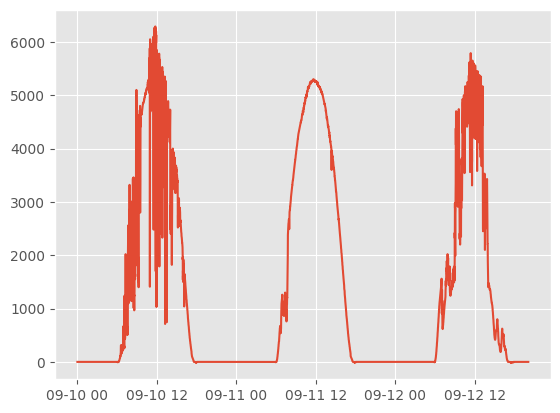

In [12]:


# Show the plot
plt.style.use('ggplot')
plt.plot(power_df['Date and Time'], power_df['AVG power'])
plt.show()

